In [1]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict

DB = '../data/humans_clean.sqlite3'

WESTERN_COUNTRIES = {
    'United States', 'Washington, D.C.', 'Germany', 'France', 'Poland',
    'Netherlands', 'Kingdom of the Netherlands', 'United Kingdom', 'Wales',
    'Italy', 'Kingdom of Italy', 'Spain', 'Sweden', 'Norway', 'Finland',
    'Denmark', 'Faroe Islands', 'Austria', 'Belgium', 'Switzerland',
    'Portugal', 'Czech Republic', 'Slovakia', 'Greece', 'Hungary',
    'Ireland', 'Canada', 'Australia', 'New Zealand', 'Romania', 'Croatia',
    'Serbia', 'Slovenia', 'Lithuania', 'Latvia', 'Estonia', 'Bulgaria',
    'Iceland', 'Luxembourg', 'Liechtenstein', 'Andorra', 'Cyprus',
    'Vatican City', 'Weimar Republic', 'German Reich',
}

In [2]:
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

# --- Classify catalogs using country_name from identifier_types ---
cur = conn.execute('SELECT property_id, country_name FROM identifier_types')
western_pids = set()
non_western_pids = set()
unclassified_pids = set()
for pid, country in cur:
    if country and country in WESTERN_COUNTRIES:
        western_pids.add(pid)
    elif country and country != 'internationality':
        non_western_pids.add(pid)
    else:
        unclassified_pids.add(pid)

print(f"Catalog classification (from identifier_types.country_name):")
print(f"  Western:      {len(western_pids)}")
print(f"  Non-Western:  {len(non_western_pids)}")
print(f"  No country:   {len(unclassified_pids)} (excluded, includes international)")

# --- Pre-compute catalog type per individual ---
conn.execute('DROP TABLE IF EXISTS temp.w_pids')
conn.execute('CREATE TEMP TABLE w_pids (pid TEXT PRIMARY KEY)')
conn.executemany('INSERT INTO w_pids VALUES (?)', [(p,) for p in western_pids])

conn.execute('DROP TABLE IF EXISTS temp.nw_pids')
conn.execute('CREATE TEMP TABLE nw_pids (pid TEXT PRIMARY KEY)')
conn.executemany('INSERT INTO nw_pids VALUES (?)', [(p,) for p in non_western_pids])

print("\nPre-computing catalog type per individual (may take a few minutes)...")
conn.execute('DROP TABLE IF EXISTS temp.ind_cat')
conn.execute('''
    CREATE TEMP TABLE ind_cat AS
    SELECT i.wikidata_id,
           MAX(CASE WHEN wp.pid IS NOT NULL THEN 1 ELSE 0 END) as has_western,
           MAX(CASE WHEN nwp.pid IS NOT NULL THEN 1 ELSE 0 END) as has_non_western
    FROM identifiers i
    LEFT JOIN w_pids wp ON i.property_id = wp.pid
    LEFT JOIN nw_pids nwp ON i.property_id = nwp.pid
    GROUP BY i.wikidata_id
''')
conn.execute('CREATE INDEX temp.idx_ind_cat ON ind_cat(wikidata_id)')

row = conn.execute('SELECT COUNT(*), SUM(has_western), SUM(has_non_western) FROM ind_cat').fetchone()
print(f"Done! {row[0]:,} individuals with identifiers")
print(f"  Referenced by a Western catalog:     {row[1]:,} ({row[1]/row[0]*100:.1f}%)")
print(f"  Referenced by a non-Western catalog:  {row[2]:,} ({row[2]/row[0]*100:.1f}%)")

Catalog classification (from identifier_types.country_name):
  Western:      1042
  Non-Western:  394
  No country:   869 (excluded, includes international)

Pre-computing catalog type per individual (may take a few minutes)...


Done! 6,850,699 individuals with identifiers
  Referenced by a Western catalog:     4,299,532 (62.8%)
  Referenced by a non-Western catalog:  752,244 (11.0%)


In [3]:
# --- Coverage curves for 5 largest non-Western polities ---
nw_polities = [
    ('Japan',     "c.polity_name LIKE '%Japan%'"),
    ('Indonesia', "c.polity_name LIKE '%Indonesia%'"),
    ('India',     "c.polity_name LIKE '%India%' AND c.polity_name NOT LIKE '%Indochina%'"),
    ('China',     "c.polity_name LIKE '%China%' AND c.polity_name NOT LIKE '%Indochina%'"),
    ('Turkey',    "c.polity_name LIKE '%Turkey%'"),
]

coverage_results = []

for title, where in nw_polities:
    cur = conn.execute(f'''
        SELECT c.impact_year,
               COALESCE(ic.has_western, 0),
               COALESCE(ic.has_non_western, 0)
        FROM consolidate c
        LEFT JOIN ind_cat ic ON c.wikidata_id = ic.wikidata_id
        WHERE ({where}) AND c.impact_year IS NOT NULL
    ''')

    bin_total = defaultdict(int)
    bin_western = defaultdict(int)
    bin_non_western = defaultdict(int)
    yr_min, yr_max = float('inf'), float('-inf')

    for year, hw, hnw in cur:
        t = ((year + 25) // 50) * 50
        bin_total[t] += 1
        bin_western[t] += hw
        bin_non_western[t] += hnw
        yr_min = min(yr_min, year)
        yr_max = max(yr_max, year)

    complete_bins = sorted(b for b in bin_total
                           if b - 25 >= yr_min and b + 24 <= yr_max)

    w_pct = [bin_western[b] / bin_total[b] * 100 for b in complete_bins]
    nw_pct = [bin_non_western[b] / bin_total[b] * 100 for b in complete_bins]

    n = sum(bin_total.values())
    print(f"{title}: n={n:,}, bins {complete_bins[0]}\u2013{complete_bins[-1]}")
    coverage_results.append((title, yr_min, yr_max, complete_bins, w_pct, nw_pct))

Japan: n=175,933, bins 1500–2000


Indonesia: n=70,264, bins 2000–2000


India: n=51,542, bins 1750–2000


China: n=64,541, bins -450–2000


Turkey: n=36,382, bins 1950–2000


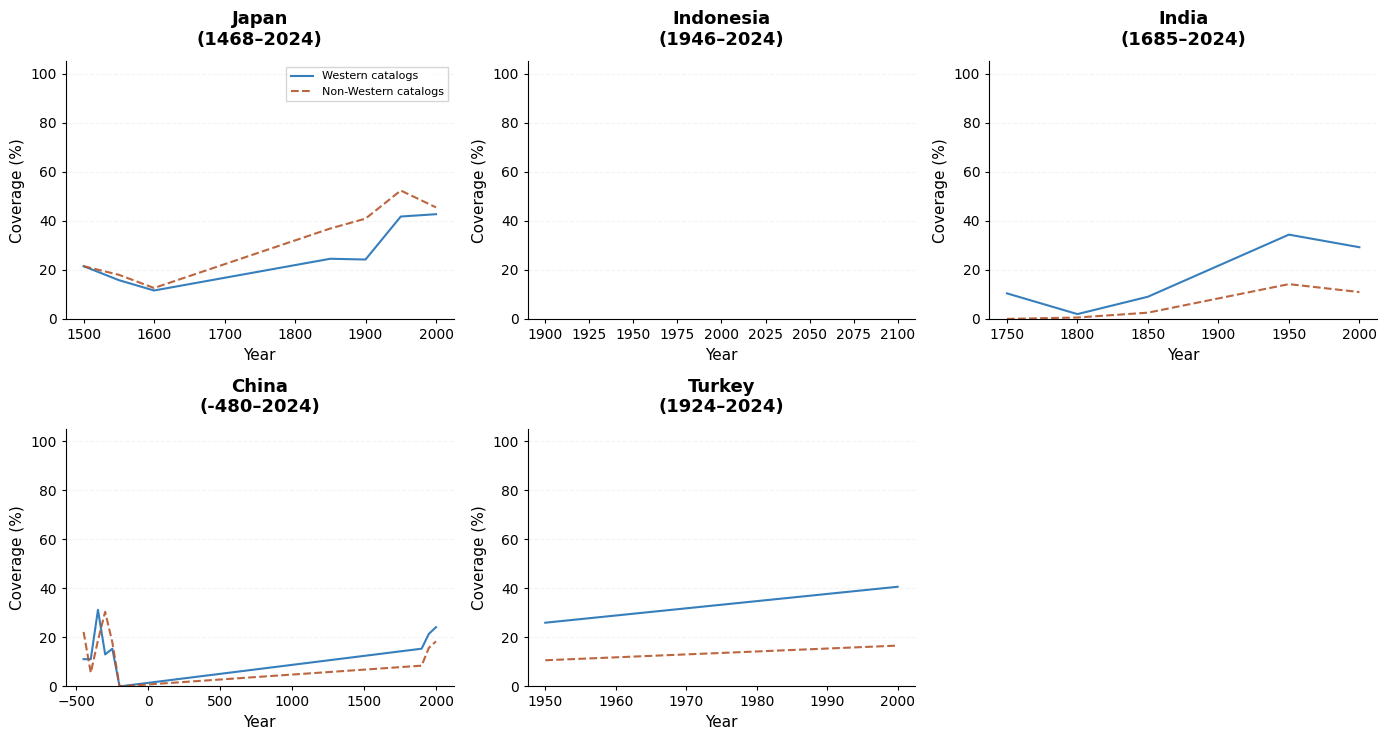

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
axes = axes.flatten()

for idx, (title, yr_start, yr_end, bins, w_pct, nw_pct) in enumerate(coverage_results):
    ax = axes[idx]

    ax.plot(bins, w_pct, '-', color='#2171b5', linewidth=1.5,
            label='Western catalogs', alpha=0.9)
    ax.plot(bins, nw_pct, '--', color='#b5542a', linewidth=1.5,
            label='Non-Western catalogs', alpha=0.9)

    ax.set_ylabel('Coverage (%)', fontsize=11)
    ax.set_xlabel('Year', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=3, labelsize=10)
    ax.grid(axis='y', alpha=0.15, linestyle='--')
    ax.set_ylim(0, 105)

    ax.set_title(f"{title}\n({yr_start}\u2013{yr_end})",
                 fontsize=13, fontweight='bold', color='black',
                 loc='center', pad=12)

    if idx == 0:
        ax.legend(fontsize=8, loc='best', frameon=True,
                  fancybox=False, edgecolor='#cccccc')

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

In [5]:
# --- Venn-style analysis: 5 regions ---
venn_regions = ['Chinese World', 'Arabic world', 'Indian World', 'Japan', 'Persian World']
venn_data = []

for region in venn_regions:
    cur = conn.execute('''
        SELECT COALESCE(ic.has_western, 0),
               COALESCE(ic.has_non_western, 0)
        FROM individuals_regions ir
        LEFT JOIN ind_cat ic ON ir.wikidata_id = ic.wikidata_id
        WHERE ir.region = ?
    ''', (region,))

    n_total = 0
    n_w_only = 0
    n_nw_only = 0
    n_both = 0
    n_neither = 0

    for hw, hnw in cur:
        n_total += 1
        if hw and hnw:
            n_both += 1
        elif hw:
            n_w_only += 1
        elif hnw:
            n_nw_only += 1
        else:
            n_neither += 1

    print(f"{region}: {n_total:,} individuals")
    print(f"  Western only:     {n_w_only:,} ({n_w_only/n_total*100:.1f}%)")
    print(f"  Non-Western only: {n_nw_only:,} ({n_nw_only/n_total*100:.1f}%)")
    print(f"  Both:             {n_both:,} ({n_both/n_total*100:.1f}%)")
    print(f"  Neither:          {n_neither:,} ({n_neither/n_total*100:.1f}%)")
    print()
    venn_data.append((region, n_w_only, n_nw_only, n_both, n_neither))

Chinese World: 175,457 individuals
  Western only:     12,860 (7.3%)
  Non-Western only: 5,596 (3.2%)
  Both:             11,233 (6.4%)
  Neither:          145,768 (83.1%)



Arabic world: 100,989 individuals
  Western only:     22,174 (22.0%)
  Non-Western only: 2,985 (3.0%)
  Both:             11,178 (11.1%)
  Neither:          64,652 (64.0%)



Indian World: 88,294 individuals
  Western only:     17,282 (19.6%)
  Non-Western only: 877 (1.0%)
  Both:             7,876 (8.9%)
  Neither:          62,259 (70.5%)



Japan: 217,072 individuals
  Western only:     24,023 (11.1%)
  Non-Western only: 28,412 (13.1%)
  Both:             66,578 (30.7%)
  Neither:          98,059 (45.2%)



Persian World: 36,396 individuals
  Western only:     5,697 (15.7%)
  Non-Western only: 587 (1.6%)
  Both:             3,003 (8.3%)
  Neither:          27,109 (74.5%)



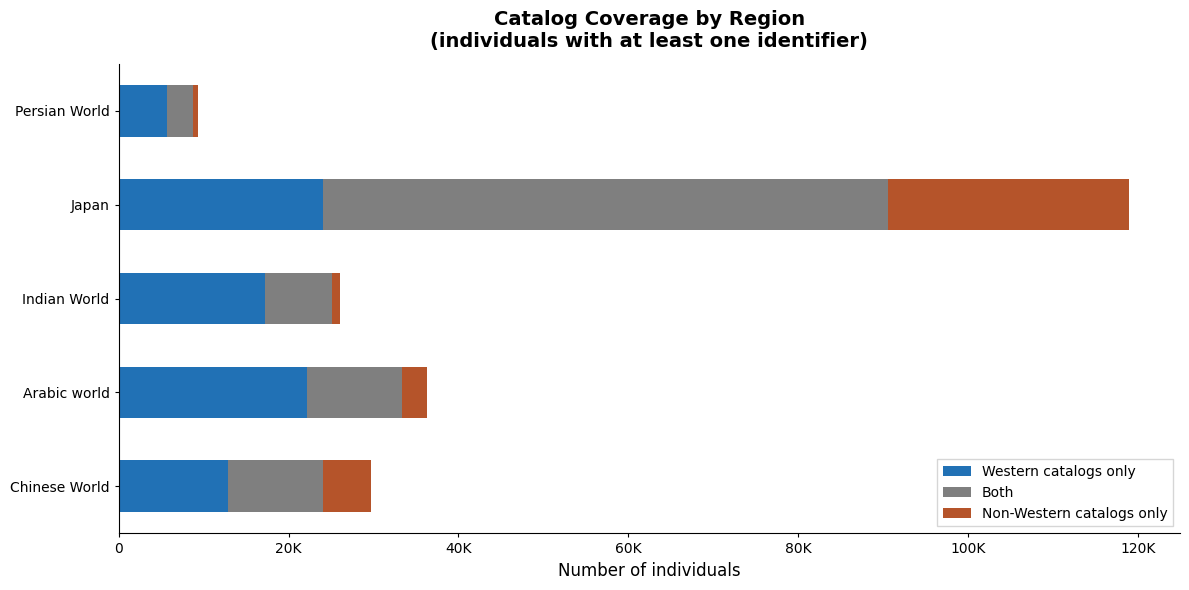

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

labels = [r for r, _, _, _, _ in venn_data]
w_only  = np.array([w for _, w, _, _, _ in venn_data])
nw_only = np.array([nw for _, _, nw, _, _ in venn_data])
both    = np.array([b for _, _, _, b, _ in venn_data])

y = np.arange(len(labels))
height = 0.55

ax.barh(y, w_only, height=height, color='#2171b5', label='Western catalogs only')
ax.barh(y, both, height=height, left=w_only, color='#7f7f7f', label='Both')
ax.barh(y, nw_only, height=height, left=w_only + both, color='#b5542a',
        label='Non-Western catalogs only')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('Number of individuals', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', length=3, labelsize=10)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'
))
ax.legend(fontsize=10, loc='lower right', frameon=True,
          fancybox=False, edgecolor='#cccccc')

ax.set_title('Catalog Coverage by Region\n(individuals with at least one identifier)',
             fontsize=14, fontweight='bold', color='black',
             loc='center', pad=12)

plt.tight_layout()
plt.show()

In [7]:
# --- Top 10 polities by share of non-Western-only individuals (min 2000 total) ---
cur = conn.execute('''
    SELECT c.polity_name,
           COUNT(*)                                                                                             AS total,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=1 AND COALESCE(ic.has_non_western,0)=0 THEN 1 ELSE 0 END)  AS w_only,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=1 AND COALESCE(ic.has_non_western,0)=1 THEN 1 ELSE 0 END)  AS both_cat,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=1 THEN 1 ELSE 0 END)  AS nw_only,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0 THEN 1 ELSE 0 END)  AS neither
    FROM consolidate c
    LEFT JOIN ind_cat ic ON c.wikidata_id = ic.wikidata_id
    WHERE c.polity_name IS NOT NULL
    GROUP BY c.polity_name
    HAVING total >= 2000
''')

raw_rows = cur.fetchall()

# Clean up display names: pick the first non-parenthesised part
def clean_polity_name(compound):
    for part in compound.split(';'):
        part = part.strip()
        if not part.startswith('('):
            return part
    return compound.split(';')[0].strip('() ')

# De-duplicate: keep only the row with the highest nw_only for each display name
seen = {}
for polity_name, total, w_only, both_cat, nw_only, neither in raw_rows:
    display = clean_polity_name(polity_name)
    if display not in seen or nw_only > seen[display][4]:
        seen[display] = (polity_name, total, w_only, both_cat, nw_only, neither)

# Sort by nw_only SHARE descending, take top 10
polity_rows = sorted(seen.values(), key=lambda r: r[4] / r[1], reverse=True)[:10]

print(f"{'Polity':<40} {'Total':>8} {'W only':>8} {'Both':>8} {'NW only':>8} {'None':>8} {'NW %':>6}")
print('-' * 90)
for polity_name, total, w_only, both_cat, nw_only, neither in polity_rows:
    display = clean_polity_name(polity_name)
    print(f"{display:<40} {total:>8,} {w_only:>8,} {both_cat:>8,} {nw_only:>8,} {neither:>8,} {nw_only/total*100:>5.1f}%")

Polity                                      Total   W only     Both  NW only     None   NW %
------------------------------------------------------------------------------------------
Oriental Republic of Uruguay               16,418      849    2,745    9,190    3,634  56.0%
Russian Federation                         68,539    9,533    7,692   15,746   35,568  23.0%
Republic of Indonesia                      93,326    3,549      854   19,345   69,578  20.7%
Iraqi Republic                              3,047      397      262      528    1,860  17.3%
Hungarian Republic                          2,096      514       31      350    1,201  16.7%
Federated Republic of Brazil               12,284    2,227    1,186    1,991    6,880  16.2%
Empire of Japan                            35,603    1,286    9,283    5,700   19,334  16.0%
Tanzania                                    3,425      192       69      540    2,624  15.8%
Brazilian Republic                         13,972    1,414      409    2

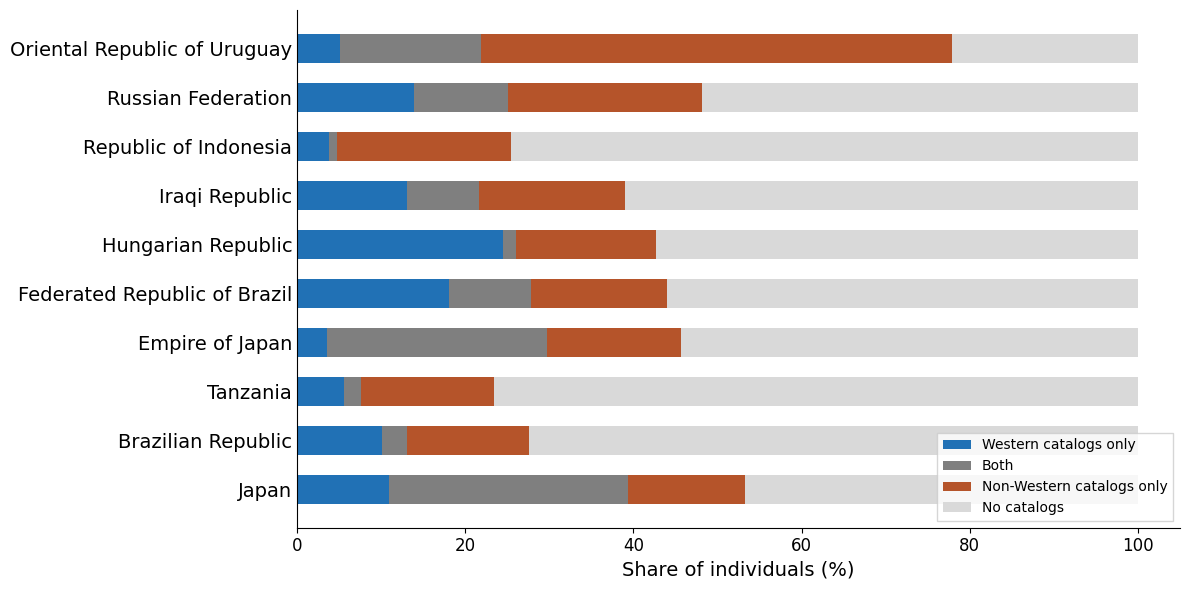

In [8]:
# --- Horizontal stacked bar: catalog coverage (%) with "No catalogs" segment ---
labels_p   = [clean_polity_name(r[0]) for r in polity_rows]
totals     = np.array([r[1] for r in polity_rows], dtype=float)
w_only_p   = np.array([r[2] for r in polity_rows]) / totals * 100
both_p     = np.array([r[3] for r in polity_rows]) / totals * 100
nw_only_p  = np.array([r[4] for r in polity_rows]) / totals * 100
neither_p  = np.array([r[5] for r in polity_rows]) / totals * 100

# Reverse so the highest nw_only share is at the top
labels_p   = labels_p[::-1]
w_only_p   = w_only_p[::-1]
both_p     = both_p[::-1]
nw_only_p  = nw_only_p[::-1]
neither_p  = neither_p[::-1]

y = np.arange(len(labels_p))
height = 0.6

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(y, w_only_p,  height=height, color='#2171b5', label='Western catalogs only')
ax.barh(y, both_p,    height=height, left=w_only_p, color='#7f7f7f', label='Both')
ax.barh(y, nw_only_p, height=height, left=w_only_p + both_p, color='#b5542a',
        label='Non-Western catalogs only')
ax.barh(y, neither_p, height=height, left=w_only_p + both_p + nw_only_p,
        color='#d9d9d9', label='No catalogs')

ax.set_yticks(y)
ax.set_yticklabels(labels_p, fontsize=14)
ax.set_xlabel('Share of individuals (%)', fontsize=14)
ax.set_xlim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', length=0)
ax.legend(fontsize=10, loc='lower right', frameon=True,
          fancybox=False, edgecolor='#cccccc')

plt.tight_layout()
plt.show()

In [9]:
# --- Japan: all individuals with their catalog category ---
import pandas as pd

cur = conn.execute('''
    SELECT c.wikidata_id,
           c.name_en,
           c.occupations,
           c.impact_year,
           c.gender,
           COALESCE(ic.has_western, 0)     AS has_western,
           COALESCE(ic.has_non_western, 0)  AS has_non_western
    FROM consolidate c
    LEFT JOIN ind_cat ic ON c.wikidata_id = ic.wikidata_id
    WHERE c.polity_name LIKE '%Japan%'
''')

rows = cur.fetchall()
df_japan = pd.DataFrame(rows, columns=[
    'wikidata_id', 'name', 'occupations', 'impact_year', 'gender',
    'has_western', 'has_non_western',
])

# Assign a human-readable category
def catalog_category(row):
    w, nw = row['has_western'], row['has_non_western']
    if w and nw:
        return 'Both'
    elif w:
        return 'Western only'
    elif nw:
        return 'Non-Western only'
    return 'No catalogs'

df_japan['catalog_category'] = df_japan.apply(catalog_category, axis=1)
df_japan = df_japan.drop(columns=['has_western', 'has_non_western'])

print(f"Japan — {len(df_japan):,} individuals")
print(df_japan['catalog_category'].value_counts().to_string())
df_japan

Japan — 219,604 individuals
catalog_category
No catalogs         105859
Both                 61260
Non-Western only     31229
Western only         21256


,wikidata_id,name,occupations,impact_year,gender,catalog_category
0,Q1000588,Chiharu Matsuyama,composer; singer-songwriter; recording artist;...,1990.0,male,Both
1,Q1000600,Godai Tomoatsu,samurai; businessperson,1871.0,male,Both
2,Q1000626,Hiroshi Yanaka,actor; seiyū,1993.0,male,Both
3,Q100063177,Raizō Kanda,businessperson,1907.0,male,Both
4,Q100138247,Haruki Noguchi,motorcycle racer,2023.0,male,Western only
...,...,...,...,...,...,...
219599,Q99973273,Yûya Ogawa,actor,NaN,NaN,Both
219600,Q99983081,Hiromichi Ogane,entomologist,NaN,NaN,No catalogs
219601,Q99983994,Taiji Nishizawa,NaN,1965.0,NaN,Non-Western only
219602,Q99986866,Lin Qiujin,music educator; singer; classical singer,1944.0,female,No catalogs


In [10]:
# --- Top 3 Western and top 3 non-Western catalogs (by number of individuals) ---
cur = conn.execute('''
    SELECT it.property_id, it.name_en, it.country_name, COUNT(*) AS n
    FROM identifiers i
    JOIN identifier_types it ON i.property_id = it.property_id
    WHERE it.country_name IS NOT NULL
    GROUP BY it.property_id
    ORDER BY n DESC
''')

western_top = []
non_western_top = []
for pid, name, country, n in cur:
    if country in WESTERN_COUNTRIES and len(western_top) < 3:
        western_top.append((name, country, n))
    elif country not in WESTERN_COUNTRIES and len(non_western_top) < 3:
        non_western_top.append((name, country, n))
    if len(western_top) == 3 and len(non_western_top) == 3:
        break

print("Top 3 Western catalogs:")
for name, country, n in western_top:
    print(f"  {name} ({country}): {n:,} individuals")

print("\nTop 3 non-Western catalogs:")
for name, country, n in non_western_top:
    print(f"  {name} ({country}): {n:,} individuals")

Top 3 Western catalogs:
  GND ID (Germany): 2,076,608 individuals
  Library of Congress authority ID (United States): 1,185,389 individuals
  IdRef ID (France): 751,282 individuals

Top 3 non-Western catalogs:
  OpenSanctions ID (internationality): 188,939 individuals
  CiNii Research ID (Japan): 178,002 individuals
  Film.ru person ID (Russia): 171,167 individuals


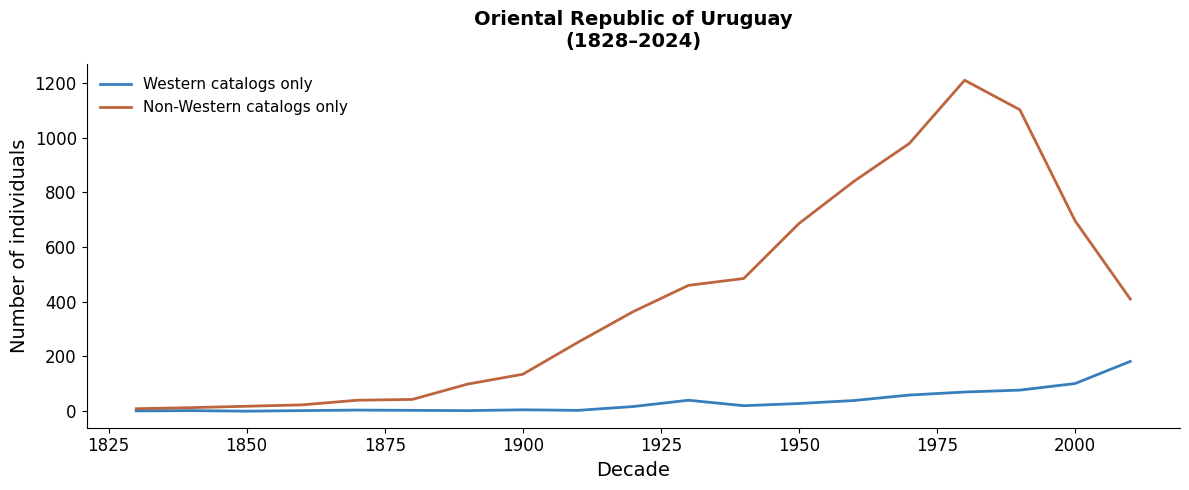

In [11]:
# --- Uruguay: Western-only vs Non-Western-only individuals per decade ---
cur = conn.execute('''
    SELECT c.impact_year,
           COALESCE(ic.has_western, 0)  AS hw,
           COALESCE(ic.has_non_western, 0) AS hnw
    FROM consolidate c
    LEFT JOIN ind_cat ic ON c.wikidata_id = ic.wikidata_id
    WHERE c.polity_name LIKE '%Uruguay%'
      AND c.impact_year IS NOT NULL
''')

decade_w_only = defaultdict(int)
decade_nw_only = defaultdict(int)
yr_min, yr_max = float('inf'), float('-inf')

for year, hw, hnw in cur:
    decade = (year // 10) * 10
    yr_min = min(yr_min, year)
    yr_max = max(yr_max, year)
    if hw and not hnw:
        decade_w_only[decade] += 1
    elif hnw and not hw:
        decade_nw_only[decade] += 1

# Only complete decades
decades = sorted(d for d in set(decade_w_only) | set(decade_nw_only)
                 if d >= yr_min and d + 9 <= yr_max)
w_counts  = [decade_w_only[d] for d in decades]
nw_counts = [decade_nw_only[d] for d in decades]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(decades, w_counts, '-', color='#2171b5', linewidth=2,
        label='Western catalogs only', alpha=0.9)
ax.plot(decades, nw_counts, '-', color='#b5542a', linewidth=2,
        label='Non-Western catalogs only', alpha=0.9)

ax.set_xlabel('Decade', fontsize=14)
ax.set_ylabel('Number of individuals', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=11, frameon=False)

ax.set_title(f'Oriental Republic of Uruguay\n({yr_min}\u2013{yr_max})',
             fontsize=14, fontweight='bold', color='black', pad=12)

plt.tight_layout()
plt.show()

In [12]:
conn.close()